# Create Pipeline in Machine Learning
This is just a simple explaination on how to create a Pipeline in Machine Learning. In this example, we’ll use the scikit-learn. Once we have a better understanding of Pipeline, we can implement it with any ML or DL models.

# Whats is ML Pipeline?

Before we start, lets understad what exactly PipeLine is.

Generally, a machine learning pipeline describes or models your ML process : writing code, releasing it to production, performing data extractions, creating training models, and tuning the algorithm.

An ML pipeline should be a continuous process as a team works on their ML platform.

Machine learning programs involve a series of steps to get the data ready before feeding it into the ML model. Those steps can include:

* Reading the data and converting it to a Pandas dataframe
* Dropping or adding some columns
* Running some calculations over the columns
* Normalizing the data

We have to be tie all the above together for an ML model to execute and produce results successfully.

We can use the Pipeline object to do this one step after another.

A pipeline is a generalized but very important concept for a Data Scientist. In software engineering, people build pipelines to develop software that is exercised from source code to deployment. Similarly, in ML, a pipeline is created to allow data flow from its raw format to some useful information. It provides a mechanism to construct a multi-ML parallel pipeline system in order to compare the results of several ML methods.

Each step in a pipeline is fed data processed from its preceding step; that is, the output of a processing unit is supplied as the input to the next step.

We could compare the ML Pipeline with Water flow pipeline. The data flows through the pipeline just as water flows in a pipe.

Mastering the pipeline concept is a powerful way to create error-free ML models, and pipelines are a crucial element of an AutoML system.



# Why ML Pipeline?

The key benefit of Machine Learning Pipeline is to automate the model life cycle steps.

Say at first we have gone through various steps from data validation; clean the data, pre-processing; creating or dropping features; model training etc on the training dataset.

Now based on the business requirement we have to re-train our model based on new training data.

Going through the same steps manually on this new training data will be very costly, also there will be some possibility of human error.

In-short Implementing PipeLine for continuously updating models will be beneficial, as this will reduce the burden; reduce cost; reduce chance of introducing error.

# When to use PipeLine in Machine Learning?

Machine learning pipelines provide a variety of advantages, but not every data science project needs a pipeline. as mentioned earlier, PipeLine should mainly be used for continuously updating models like the applications from where continuous updates are received such as Fraud Detection ML Application; Spam Email Detection; Health Industry; Product Review; Recommendation System etc... these are the systems which keep on changing real-time; near real-time; batched; or so.

At times, we do use some data science projects for experiment with a new model, investigate a new model architecture; one time analysis on training dataset etc.. in such scenario ML Pipeline may not be much beneficial.



# Prerequisite for building PipeLine in ML
To build a machine learning pipeline, the first requirement is to define the structure of the pipeline.

In other words, we must list down the exact steps which would go into our machine learning pipeline.

In order to do so, we will build a prototype machine learning model on the existing data before we create a pipeline. The main idea behind building a prototype is to understand the data and necessary preprocessing steps required before the model building process. Based on our learning from the prototype model, we will design a machine learning pipeline that covers all the essential preprocessing steps.

In here we will not focus on building a prototype considering that you already have some basic idea on how to explore the data; going through the individual variables; cleaning data; EDA; Feature Engineering; Fature Selection; Feature Extraction etc, to make it ready for the model.

# Working of MP Pipeline

You stack up functions in the order that you want to run them. These are called `transformers`.

One can also create a custom transformer then use one built into scikit-learn.

The format is:

Pipeline constructor with tuples of (‘a descriptive name’, a function). You can pass arguments to the function’s, init() method where it says some args.

Each method must implement the fit() and transform() functions.

Except the last function only implements fit(), and generally used for ML Modelling, this is called as Estimator.

> pipeline = Pipeline([
>     ('step_1', function1(some args)),
>     ('step_2', function2())
> ])

# Basic and Simple Example

Let’s look at an basic and simple example, for this will use Iris dataaset.

As a basic step we will first import the required libraires and then load Iris dataset from scikit-learn's, refer http://scikit-learn.org/stable/auto_examples/datasets/plot_iris_dataset.html for details.

The dataset consists of four features and has 150 rows (how do i know this? its all defined on the scikit-learn site shared above).

We will be developing the following steps in a pipeline to train our model using the Iris dataset.

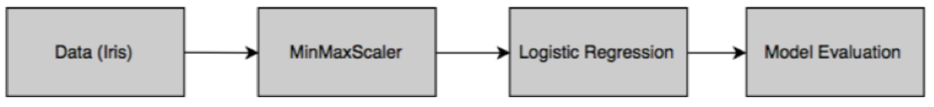

The problem statement is to predict the species of an Iris data using four different features.

In this simple pipeline, we will be using MinMaxScaler method to scale the input data and logistic regression as its a Classification problem, to predict the species of the Iris.

The model will then be evaluated based on the accuracy measure.

## Step 1 : Import libraries

In [1]:
import pandas as pd
import numpy as np

from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

from sklearn.metrics import accuracy_score

from sklearn.pipeline import Pipeline

## Step 2 : Load dataset
The next step is to load the iris data and then we split it into training and test datasets.

We will use 80% of the dataset to train the model and the remaining 20% to test the accuracy of the model.

We can use the shape function to view the dimension of the dataset.

As our focus in-here is to create PipeLine, so we will not go into EDA and Visualization part.

In [2]:
iris = load_iris()

In [3]:
X_train, X_test, y_train, y_test = train_test_split(iris.data, iris.target, test_size= 0.2,random_state=10 )

In [4]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((120, 4), (120,), (30, 4), (30,))

So now we have training dataset with 4 columns and 120 rows, which equates to 80% of the Iris dataset and is as expected.
and test dataset with 4 columns and 30 rows, which equates to 20% of the Iris dataset and is as expected.

150 Total Rows : 80% of 150 is 120.

In [5]:
X_train[:5]

array([[6.6, 2.9, 4.6, 1.3],
       [6.2, 2.9, 4.3, 1.3],
       [7.2, 3. , 5.8, 1.6],
       [5.8, 2.8, 5.1, 2.4],
       [6.3, 2.5, 5. , 1.9]])

## Step 3 : Create PipeLine
The next step is to create a pipeline.

The pipeline object is in the form of (key, value) pairs. Where `Key` is a string that has the name for a particular step and value is the name of the function or actual method.

In the following code snippet, we have named the MinMaxScaler() method as scale and LogisticRegression() as clf:

In [6]:
my_pipeline = Pipeline(
    [
        (
            'scale', MinMaxScaler() # `transformers`
        ),
        (
            'clf', LogisticRegression() # Estimator
        )
    ]
)

As mentioned above, the last step will just have fit() method, so it make sense that we do fit to our model or classifier.

And all above will have both fit() and transform() methods, in our case step scale will use fit() and transform() method.

## Step 4 : Fit the PipeLine
Then, we fit the pipeline object, my_pipeline, to the training dataset.

In [7]:
my_pipeline.fit(X_train, y_train)

Pipeline(steps=[('scale', MinMaxScaler()), ('clf', LogisticRegression())])

On executing the `.fit()` method on pipeline object, we will get to see the pipeline details of the fitted model that was built.

Alternatively we can check the Pipeline detail or structure graphically as below

In [8]:
from sklearn import set_config
set_config(display='diagram')
my_pipeline

Pipeline(steps=[('scale', MinMaxScaler()), ('clf', LogisticRegression())])

## Step 5 : Evaluate the Model or Pipeline
The last step is to score the model on the test dataset using the score method's

In [9]:
score = my_pipeline.score(X_test, y_test)
print('Logistic Regression pipeline test accuracy: %.3f' % score)

Logistic Regression pipeline test accuracy: 0.967


As we can note from the following results, the accuracy of the model is 0.967, which is 96%

Alternatively, we can also use `.predict()` to predicting the test dataset.

In [10]:
pred = my_pipeline.predict(X_test)
print(accuracy_score(y_test, pred))

0.9666666666666667


## Conclusion :
In this example, we created a pipeline with two steps, that is, Min Max Scaling and LogisticRegression(). When we executed the fit method on my_pipeline, the MinMaxScaler performed a fit and transform method on the input data, and it was passed on to the estimator, which is a logistic regression model. These intermediate steps in a pipeline are known as transformers, and the last step is an estimator.

# Handling NaN / Blank / Null / Missing Data using PipeLine


In [11]:
from sklearn.datasets import fetch_openml

In [12]:
# Load data from https://www.openml.org/d/40945
X, y = fetch_openml("titanic", version=1, as_frame=True, return_X_y=True)

c:\Users\supri\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\datasets\_openml.py:1022: FutureWarning: The default value of `parser` will change from `'liac-arff'` to `'auto'` in 1.4. You can set `parser='auto'` to silence this warning. Therefore, an `ImportError` will be raised from 1.4 if the dataset is dense and pandas is not installed. Note that the pandas parser may return different data types. See the Notes Section in fetch_openml's API doc for details.
  warn(


In [13]:
X.dtypes
# X['age'].dtypes

pclass        float64
name           object
sex          category
age           float64
sibsp         float64
parch         float64
ticket         object
fare          float64
cabin          object
embarked     category
boat           object
body          float64
home.dest      object
dtype: object

In [14]:
# Get list of columns whose data type is object i.e. string
# cat_f = list((X.dtypes[X.dtypes == np.object]).index)
# cat_f = list((X.dtypes[X.dtypes != np.float]).index)
# cat_f

We will train our classifier with the following features only:

**Numeric Features:**

* age: float;
* fare: float.

**Categorical Features:**

* embarked: categories encoded as strings {'C', 'S', 'Q'};
* sex: categories encoded as strings {'female', 'male'};
* pclass: ordinal integers {1, 2, 3}.

In [15]:
numeric_features = ['age', 'fare']
categorical_features = ['embarked', 'sex', 'pclass']

In [16]:
# Check for Null Values.
X.isnull().sum()

pclass          0
name            0
sex             0
age           263
sibsp           0
parch           0
ticket          0
fare            1
cabin        1014
embarked        2
boat          823
body         1188
home.dest     564
dtype: int64

Lets create the preprocessing pipelines for both numeric and categorical data.

In [17]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [18]:
# Two ways to create the Pipeline..

# numeric_transformer = Pipeline(steps = [
#     ('imputer', SimpleImputer(strategy='median')),
#     ('scaler', StandardScaler())])

# Alternate way.
numeric_transformer = Pipeline(
    [
        (
            'imputer', SimpleImputer(strategy='median')
        ),
        (
            'scaler', StandardScaler()
        )
    ]
)

In [19]:
categorical_transformer = Pipeline(
    [
        (
            'imputer', SimpleImputer(strategy='constant', fill_value='missing')
        ),
        (
            'onehot', OneHotEncoder(handle_unknown='ignore')
        )
    ]
)

In [20]:
from sklearn.compose import ColumnTransformer

In [21]:
preprocessor = ColumnTransformer(
    [
        (
            'num', numeric_transformer, numeric_features
        ),
        (
            'cat', categorical_transformer, categorical_features
        )
    ]
)

In [22]:
my_pipeline2 = Pipeline(
    [
        (
            'preprocessor', preprocessor
        ),
        (
            'clf', LogisticRegression()
        )
    ]
)

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [24]:
X_train[numeric_features].head()

,age,fare
1243,NaN,7.2250
528,NaN,0.0000
1121,NaN,22.3583
101,39.0,29.7000
381,30.0,13.0000


In [25]:
processed_data = numeric_transformer.fit_transform(X_train[numeric_features])
processed_data[:5]

array([[-0.12818854, -0.48941241],
       [-0.12818854, -0.62667538],
       [-0.12818854, -0.20190489],
       [ 0.7175327 , -0.06242481],
       [ 0.02557896, -0.37969702]])

In [26]:
X_train[categorical_features].head()

,embarked,sex,pclass
1243,C,male,3.0
528,S,male,2.0
1121,C,male,3.0
101,C,male,1.0
381,S,female,2.0


In [27]:
processed_data2 = categorical_transformer.fit_transform(X_train[categorical_features])
processed_data2

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 3141 stored elements and shape (1047, 9)>

In [28]:
my_pipeline2.fit(X_train, y_train)

print("model score: %.3f" % my_pipeline2.score(X_test, y_test))

model score: 0.786


# Working with Categorical Features with PipeLine
Many machine learning algorithms require that their input is numerical and therefore categorical features must be transformed into numerical features before we can use any of these algorithms.

One of the most common ways to make this transformation is to `one-hot` encode the categorical features, especially when there does not exist a natural ordering between the categories (e.g. a feature ‘City’ with names of cities such as ‘London’, ‘Lisbon’, ‘Berlin’, etc.). For each unique value of a feature (say, ‘London’) one column is created (say, ‘City_London’) where the value is 1 if for that instance the original feature takes that value and 0 otherwise.

In [29]:
employees = [
    ('Matt', 34, 'Nashville', 155),
    ('Sanjay', 31, 'Kerala', 177.5),
    ('Rohan', 16, 'Mumbai', 81),
    ('Karan', 31, 'Indore', 167),
    ('Mayank', 12, 'Indore', 144),
    ('Anjali', 35, 'Mumbai', 135),
    ('Virginia', 35, 'Columbia', 111),
    ('Euel', 35, 'Brazil', 113),
    ('Carlos', 35, 'Peru', 187.44)
]

# Create a DataFrame object
df = pd.DataFrame(employees, columns=['Name', 'Age', 'City', 'Marks'])

In [30]:
df

,Name,Age,City,Marks
0,Matt,34,Nashville,155.00
1,Sanjay,31,Kerala,177.50
2,Rohan,16,Mumbai,81.00
3,Karan,31,Indore,167.00
4,Mayank,12,Indore,144.00
5,Anjali,35,Mumbai,135.00
6,Virginia,35,Columbia,111.00
7,Euel,35,Brazil,113.00
8,Carlos,35,Peru,187.44


In [31]:
numeric_features = ['Age', 'Marks']
categorical_features = [ 'City']
drop_feature = ['Name']

In [32]:
pre_process = ColumnTransformer(
    remainder = 'passthrough',
    transformers = [
        ('drop_columns', 'drop', drop_feature),
        ('onehot', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

In [33]:
processed_df = pd.DataFrame(pre_process.fit_transform(df))
processed_df

,0,1,2,3,4,5,6,7,8
0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,34.0,155.00
1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,31.0,177.50
2,0.0,0.0,0.0,0.0,1.0,0.0,0.0,16.0,81.00
3,0.0,0.0,1.0,0.0,0.0,0.0,0.0,31.0,167.00
4,0.0,0.0,1.0,0.0,0.0,0.0,0.0,12.0,144.00
5,0.0,0.0,0.0,0.0,1.0,0.0,0.0,35.0,135.00
6,0.0,1.0,0.0,0.0,0.0,0.0,0.0,35.0,111.00
7,1.0,0.0,0.0,0.0,0.0,0.0,0.0,35.0,113.00
8,0.0,0.0,0.0,0.0,0.0,0.0,1.0,35.0,187.44


# Custom Transformation and PipeLine

In [34]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [35]:
df = pd.read_csv('https://raw.githubusercontent.com/werowe/tripAdvisorNeuralNetworkTensorFlow/master/TripAdvisor.csv',sep=',',header=0)

In [36]:
df.head()

,User country,Nr. reviews,Nr. hotel reviews,Helpful votes,Score,Period of stay,Traveler type,Pool,Gym,Tennis court,Spa,Casino,Free internet,Hotel name,Hotel stars,Nr. rooms,User continent,Member years,Review month,Review weekday
0,USA,11,4,13,5,Dec-Feb,Friends,NO,YES,NO,NO,YES,YES,Circus Circus Hotel & Casino Las Vegas,3,3773,North America,9,January,Thursday
1,USA,119,21,75,3,Dec-Feb,Business,NO,YES,NO,NO,YES,YES,Circus Circus Hotel & Casino Las Vegas,3,3773,North America,3,January,Friday
2,USA,36,9,25,5,Mar-May,Families,NO,YES,NO,NO,YES,YES,Circus Circus Hotel & Casino Las Vegas,3,3773,North America,2,February,Saturday
3,UK,14,7,14,4,Mar-May,Friends,NO,YES,NO,NO,YES,YES,Circus Circus Hotel & Casino Las Vegas,3,3773,Europe,6,February,Friday
4,Canada,5,5,2,4,Mar-May,Solo,NO,YES,NO,NO,YES,YES,Circus Circus Hotel & Casino Las Vegas,3,3773,North America,7,March,Tuesday


In [37]:
df.shape

(504, 20)

In [38]:
cols = df.columns
cols

Index(['User country', 'Nr. reviews', 'Nr. hotel reviews', 'Helpful votes',
       'Score', 'Period of stay', 'Traveler type', 'Pool', 'Gym',
       'Tennis court', 'Spa', 'Casino', 'Free internet', 'Hotel name',
       'Hotel stars', 'Nr. rooms', 'User continent', 'Member years',
       'Review month', 'Review weekday'],
      dtype='object')

In [39]:
cat_cols = ['User country',  'Period of stay', 'Traveler type', 'Pool', 'Gym',
       'Tennis court', 'Spa', 'Casino', 'Free internet', 'Hotel name',
       'User continent',
       'Review month', 'Review weekday','Hotel stars']

In [40]:
from sklearn.base import BaseEstimator, TransformerMixin

In [41]:
class ToNumbers(BaseEstimator, TransformerMixin):
    def __init__(self, cat_cols):
        self.cat_cols = cat_cols
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        for c in cat_cols:
            encoded, categories = X[c].factorize()
            X[c] = encoded
        return X.values

`.factorize()` method helps to get the numeric representation of an array by identifying distinct values. This method is available as both pandas.factorize() and Series.factorize().

In [42]:
pipeline = Pipeline([
    ('toNumbers', ToNumbers(cat_cols)),
    ('scaler', StandardScaler())
])

processed_df = pipeline.fit_transform(df)

In [43]:
processed_df = pd.DataFrame(pipeline.fit_transform(df), columns=cols)
processed_df.head()

,User country,Nr. reviews,Nr. hotel reviews,Helpful votes,Score,Period of stay,Traveler type,Pool,Gym,Tennis court,Spa,Casino,Free internet,Hotel name,Hotel stars,Nr. rooms,User continent,Member years,Review month,Review weekday
0,-0.51294,-0.495595,-0.502370,-0.386857,0.871491,-1.349490,-1.577159,-4.472136,-0.223607,-0.559017,-1.788854,-0.324443,-0.223607,-1.651446,-1.382572,1.227704,-0.663338,0.102120,-1.593255,-1.620746
1,-0.51294,0.945905,0.207912,0.892215,-1.115982,-1.349490,-0.926678,-4.472136,-0.223607,-0.559017,-1.788854,-0.324443,-0.223607,-1.651446,-1.382572,1.227704,-0.663338,0.027690,-1.593255,-1.108932
2,-0.51294,-0.161914,-0.293464,-0.139295,0.871491,-0.452204,-0.276196,-4.472136,-0.223607,-0.559017,-1.788854,-0.324443,-0.223607,-1.651446,-1.382572,1.227704,-0.663338,0.015285,-1.303572,-0.597117
3,-0.41124,-0.455553,-0.377026,-0.366227,-0.122245,-0.452204,-1.577159,-4.472136,-0.223607,-0.559017,-1.788854,-0.324443,-0.223607,-1.651446,-1.382572,1.227704,0.225817,0.064905,-1.303572,-1.108932
4,-0.30954,-0.575678,-0.460589,-0.613789,-0.122245,-0.452204,0.374285,-4.472136,-0.223607,-0.559017,-1.788854,-0.324443,-0.223607,-1.651446,-1.382572,1.227704,-0.663338,0.077310,-1.013890,-0.085302


# Working on own dataset

In [ ]:
students = pd.read_csv("student-por.csv", sep=';')
students.head()

FileNotFoundError: [Errno 2] No such file or directory: '../input/student-performance-data-set/student-por.csv'